# 03 · Plot fluxes and time lag used

For each analyzer (QCL, LGR) and gas (N2O, CH4), a combined figure shows the flux
in the top panels and the time lag used in the bottom panels, with the lag
variants ([processing versions](../docs/processing-versions.md)) as columns. This
lines up each variant's flux directly above the lag that produced it.

The first three columns are the flux variants (`*-1`, `*-2R`, `*-3`), read from
the column subsets (`data/02-…_subsets/`). The fourth column is the PWB variant
(`*-4`): it has a detected time lag (`*_tlag_final_pf_s`, from
`data/01-pwb_tlag_summary_parquet/`) but no flux yet, so its flux panel is left
empty.

Four figures are saved: `figures/03_{qcl,lgr}_{n2o,ch4}.png`. These are
intermediate figures (small size / low DPI); bump `FIGSIZE` / `DPI` for
publication-ready output.

## Imports

In [11]:
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

from diive.core.io.files import load_parquet

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

In [12]:
SUBSETDIR = Path("../data/02-eddypro_fluxes_level-1_parquet_subsets")  # flux variants
PWBDIR = Path("../data/01-pwb_tlag_summary_parquet")                  # PWB (*-4) tlag
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

# Figure size / resolution. Kept small here — these are intermediate figures.
# Widened to 14 inches to fit the extra PWB column. Increase for publication output.
FIGSIZE = (14, 6)
DPI = 300

# Analysis year. The flux subsets are already restricted to this year in
# notebook 02; the PWB tlag is filtered to it here so all panels match.
YEAR = 2021

# One figure per analyzer x gas. Columns = the three flux variants plus the PWB
# (*-4) variant. The PWB run has a detected time lag but no flux, so its flux
# panel is left empty.
ANALYZERS = {
    "QCL": {"variants": ["QCL-1", "QCL-2R", "QCL-3"], "pwb": "QCL-4"},
    "LGR": {"variants": ["LGR-1", "LGR-2R", "LGR-3"], "pwb": "LGR-4"},
}
# Per gas: the flux variable (top row), the time-lag-used variable (bottom row of
# the flux variants), and the PWB final applied-lag column (bottom row, PWB).
GASES = {
    "N2O": {"flux": "FN2O", "lag": "N2O_TLAG_USED", "pwb_lag": "n2o_tlag_final_pf_s"},
    "CH4": {"flux": "FCH4", "lag": "CH4_TLAG_USED", "pwb_lag": "ch4_tlag_final_pf_s"},
}
# Distinct colors for the two rows (ColorBrewer Dark2): flux vs. lag.
FLUX_COLOR = "#1b9e77"  # teal
LAG_COLOR = "#d95f02"   # orange

# Robust flux y-range: clip the flux axis to this percentile range (per figure)
# so outliers don't flatten the signal. The lag axis is left to autoscale.
PCTL = (1, 99)

# Load the flux-variant subsets and the PWB tlag summaries, restricted to YEAR.
flux_codes = [c for a in ANALYZERS.values() for c in a["variants"]]
data = {c: load_parquet(filepath=str(SUBSETDIR / f"{c}.parquet")) for c in flux_codes}
pwb_data = {
    a["pwb"]: load_parquet(filepath=str(PWBDIR / f"{a['pwb']}_pwb_tlag.parquet"))
    for a in ANALYZERS.values()
}
data = {c: d.loc[d.index.year == YEAR] for c, d in data.items()}
pwb_data = {c: d.loc[d.index.year == YEAR] for c, d in pwb_data.items()}

for c, df in {**data, **pwb_data}.items():
    print(f"{c}: {df.shape[0]} rows x {df.shape[1]} cols")

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-1.parquet (0.005 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-2R.parquet (0.002 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-3.parquet (0.003 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-1.parquet (0.004 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-2R.parquet (0.002 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-3.parquet (0.003 seconds).

> Loaded .parquet file ..\data\01-pwb_tlag_summary_parquet\QCL-4_pwb_tlag.parquet (0.007 seconds).

> Loaded .parquet file ..\data\01-pwb_tlag_summary_parquet\LGR-4_pwb_tlag.parquet (0.008 seconds).

QCL-1: 9632 rows x 4 cols
QCL-2R: 9632 rows x 4 cols
QCL-3: 9632 rows x 4 cols
LGR-1: 7803 rows x 4 cols
LGR-2R: 7803 rows x 4 cols
LGR-3: 7803 rows x 4 cols
QCL-4: 9711 rows x 44 cols
LGR-4: 7803 rows x 44 cols


## Figures

One figure per analyzer x gas: flux (top) over time lag used (bottom), variants
as columns.

Saved ..\figures\03_qcl_n2o.png


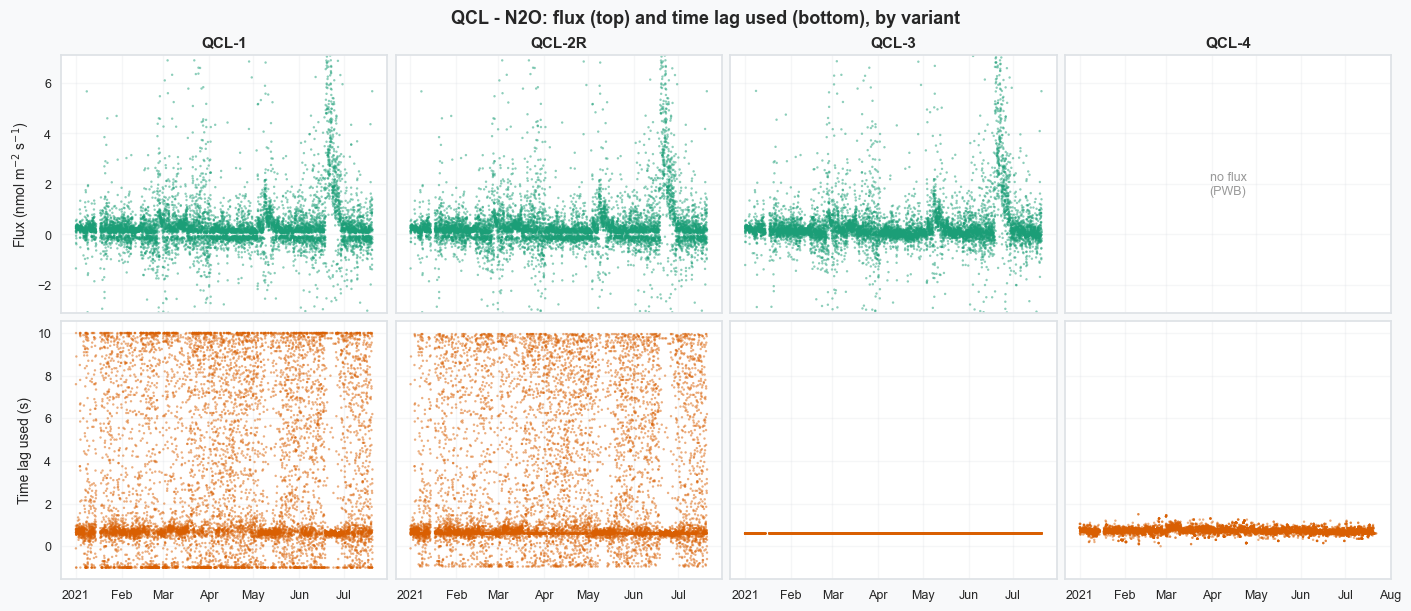

Saved ..\figures\03_qcl_ch4.png


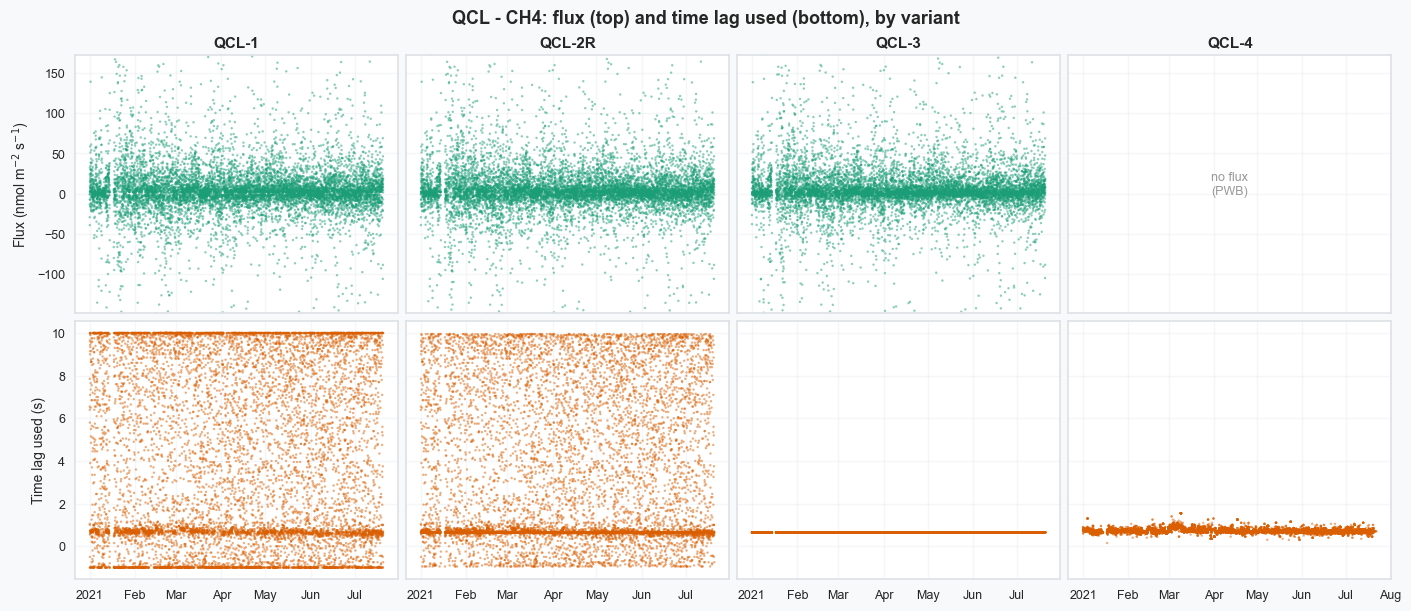

Saved ..\figures\03_lgr_n2o.png


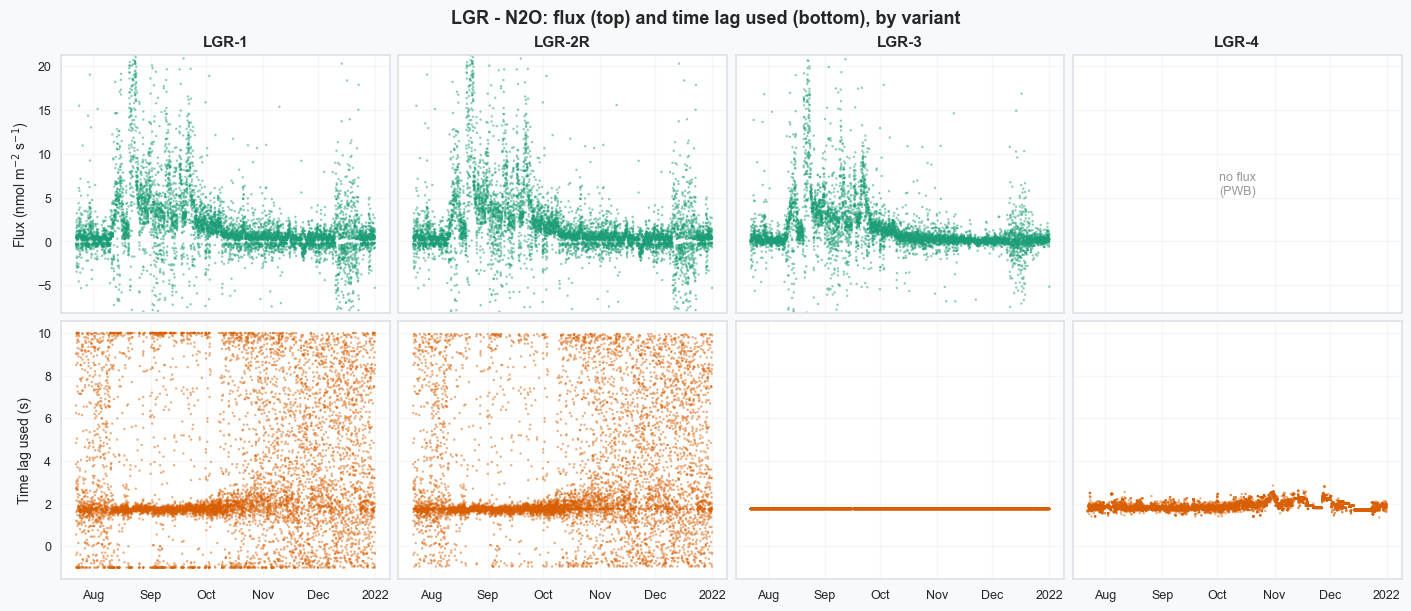

Saved ..\figures\03_lgr_ch4.png


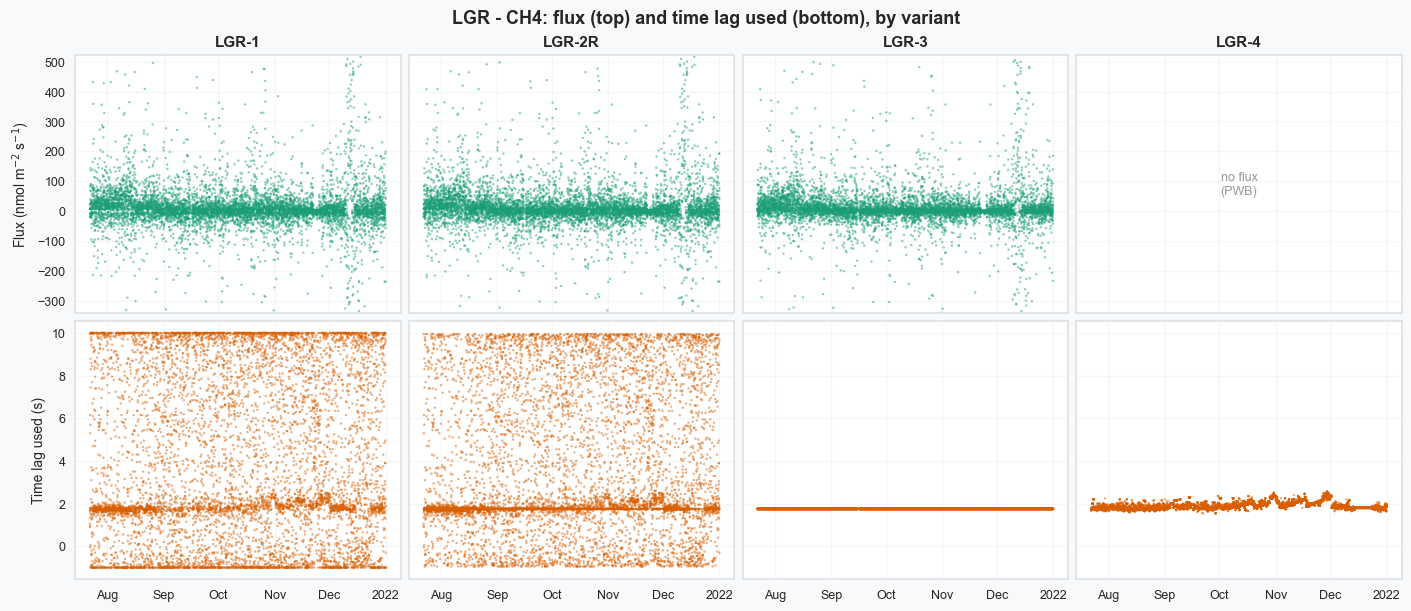

In [13]:
def robust_ylim(values, pctl=PCTL, pad_frac=0.05):
    """Percentile-based y-limits with a small symmetric pad."""
    lo, hi = np.nanpercentile(values, pctl)
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad


for analyzer, info in ANALYZERS.items():
    variants = info["variants"]
    pwb_code = info["pwb"]
    columns = variants + [pwb_code]  # PWB is the last column

    for gas, v in GASES.items():
        fluxvar, lagvar, pwb_lag = v["flux"], v["lag"], v["pwb_lag"]

        # Robust flux range from the flux variants (PWB has no flux).
        flux_vals = np.concatenate([data[c][fluxvar].to_numpy().ravel() for c in variants])
        flux_ylim = robust_ylim(flux_vals)

        fig, axes = plt.subplots(
            nrows=2, ncols=len(columns),
            figsize=FIGSIZE,
            sharex="col",   # flux and its lag share the time axis
            sharey="row",   # all flux panels share scale; all lag panels share scale
            constrained_layout=True,
        )

        for ci, code in enumerate(columns):
            ax_top, ax_bot = axes[0, ci], axes[1, ci]
            ax_top.set_title(code, fontweight="bold")
            ax_top.grid(True, alpha=0.3)
            ax_bot.grid(True, alpha=0.3)

            if code == pwb_code:
                # PWB: no flux yet, so leave the top panel empty; lag from the summary.
                ax_top.text(0.5, 0.5, "no flux\n(PWB)", ha="center", va="center",
                            transform=ax_top.transAxes, color="0.6", fontsize=9)
                pdf = pwb_data[pwb_code]
                ax_bot.scatter(pdf.index, pdf[pwb_lag], s=3, alpha=0.5,
                               color=LAG_COLOR, edgecolors="none")
            else:
                df = data[code]
                ax_top.scatter(df.index, df[fluxvar], s=3, alpha=0.5,
                               color=FLUX_COLOR, edgecolors="none")
                ax_top.set_ylim(flux_ylim)
                ax_bot.scatter(df.index, df[lagvar], s=3, alpha=0.5,
                               color=LAG_COLOR, edgecolors="none")

            # Compact, auto-fitting date axis (on the bottom row of each column).
            loc = mdates.AutoDateLocator()
            ax_bot.xaxis.set_major_locator(loc)
            ax_bot.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

        axes[0, 0].set_ylabel("Flux (nmol m$^{-2}$ s$^{-1}$)")
        axes[1, 0].set_ylabel("Time lag used (s)")
        fig.suptitle(f"{analyzer} - {gas}: flux (top) and time lag used (bottom), by variant",
                     fontsize=13, fontweight="bold")

        out = FIGDIR / f"03_{analyzer.lower()}_{gas.lower()}.png"
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"Saved {out}")
        plt.show()

## Runtime

In [14]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-06-08 16:53:19
End:      2026-06-08 16:53:30
Runtime:  0:00:10.634872
